In [9]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)
set.seed(2) 

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attachement du package : 'recipes'


L'objet suivant est masqué depuis 'package:stringr':

    fixed


L'objet suivant est masqué depuis 'package:stats':

    step




In [10]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
# data<-read.csv("train_values.csv",stringsAsFactors = T)
# data_labels<-read.csv("train_labels.csv",stringsAsFactors = T)
# datam<-merge(data,data_labels,by=c('building_id','building_id'))

In [6]:
# target_variable<-match('damage_grade', colnames(datam))
# id_loc_1 <- match('geo_level_1_id', colnames(datam))
# id_loc_2 <- match('geo_level_2_id', colnames(datam))
# id_loc_3 <- match('geo_level_3_id', colnames(datam))
# id_loc_1_vals<-sort(unique(datam[,id_loc_1]))
# id_loc_2_vals<-sort(unique(datam[,id_loc_2]))
# id_loc_3_vals<-sort(unique(datam[,id_loc_3]))
# id_loc_1_df <- data.frame(matrix(ncol = 2, nrow = length(id_loc_1_vals)))
# colnames(id_loc_1_df)<-c('id','mean')
# id_loc_2_df <- data.frame(matrix(ncol = 2, nrow = length(id_loc_2_vals)))
# colnames(id_loc_2_df)<-c('id','mean')
# id_loc_3_df <- data.frame(matrix(ncol = 2, nrow = length(id_loc_3_vals)))
# colnames(id_loc_3_df)<-c('id','mean')

# for (i in 1:length(id_loc_1_vals)){
#     id_loc_1_df[i,1]<-id_loc_1_vals[i]
#     id_loc_1_df[i,2]<-mean(filter(datam,geo_level_1_id == id_loc_1_vals[i])[,target_variable])
# }
# for (i in 1:length(id_loc_2_vals)){
#     id_loc_2_df[i,1]<-id_loc_2_vals[i]
#     id_loc_2_df[i,2]<-mean(filter(datam,geo_level_2_id == id_loc_2_vals[i])[,target_variable])
# }
# for (i in 1:length(id_loc_3_vals)){
#     id_loc_3_df[i,1]<-id_loc_3_vals[i]
#     id_loc_3_df[i,2]<-mean(filter(datam,geo_level_3_id == id_loc_3_vals[i])[,target_variable])
# }

In [18]:
# datam<-add_column(datam,geo_level_1_mean_damage = NA,.after='geo_level_1_id')
# datam<-add_column(datam,geo_level_2_mean_damage = NA,.after='geo_level_2_id')
# datam<-add_column(datam,geo_level_3_mean_damage = NA,.after='geo_level_3_id')
# id_loc_1 <- match('geo_level_1_id', colnames(datam))
# id_loc_2 <- match('geo_level_2_id', colnames(datam))
# id_loc_3 <- match('geo_level_3_id', colnames(datam))
# for (i in 1:nrow(datam)){
#     datam[i,id_loc_1+1]<-filter(id_loc_1_df,id == datam[i,id_loc_1])[1,2]
#     datam[i,id_loc_2+1]<-filter(id_loc_2_df,id == datam[i,id_loc_2])[1,2]
#     datam[i,id_loc_3+1]<-filter(id_loc_3_df,id == datam[i,id_loc_3])[1,2]
# }
#write.csv(datam,'data_geoprocessed.csv')


dataNN<-read.csv("dataNN_target_encoding.csv",stringsAsFactors = T)
id_variable <- match('building_id', colnames(dataNN))
target_variables<-match('damage_grade', colnames(dataNN))

#DO NOT FORGET processing for test values which zones could not be in training set


In [21]:
target_variables

[1] NA

In [20]:
head(dataNN)

,geo_level_1_mean_damage,geo_level_1_sd_damage,geo_level_2_mean_damage,geo_level_2_sd_damage,geo_level_3_mean_damage,geo_level_3_sd_damage,count_floors_pre_eq,age,area_percentage,height_percentage,⋯,plan_configuration_q,plan_configuration_s,plan_configuration_u,legal_ownership_status_a,legal_ownership_status_r,legal_ownership_status_v,legal_ownership_status_w,damage_grade_X1,damage_grade_X2,damage_grade_X3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,-0.7582801,-1.62291370,-0.71177035,-1.75559843,-0.6703393,-1.5954314,-1.5527243,0.1865827,-0.6866562,-1.7901472,⋯,0,0,0,0,0,1,0,0,1,0
2,1.9332117,-2.03120745,2.06482679,-3.15856423,1.9075085,-2.5853915,-0.1777897,-1.0884839,1.1340897,0.8168333,⋯,0,0,0,0,0,1,0,0,0,1
3,1.9332117,-2.03120745,2.08531393,-3.40485914,1.9075085,-2.5853915,-0.1777897,-0.8334706,0.9064964,0.2954372,⋯,0,0,0,0,0,1,0,0,0,1
4,-0.2656782,-1.63129577,-0.82977394,-0.03013402,-0.2854523,0.6567551,-0.1777897,2.9917295,-0.6866562,-0.7473550,⋯,0,0,0,0,0,1,0,0,1,0
5,0.3234872,-0.04543808,-0.05663109,0.08862635,0.5545820,0.4493042,3.9470139,0.9516228,-0.6866562,2.3810217,⋯,0,0,0,0,0,1,0,0,1,0
6,-1.7652893,1.37390680,-1.61496209,0.74577781,-1.4143729,0.6446643,-0.1777897,-1.0884839,-0.4590629,0.2954372,⋯,0,0,0,1,0,0,0,1,0,0


In [19]:
summary(dataNN)

 geo_level_1_mean_damage geo_level_1_sd_damage geo_level_2_mean_damage
 Min.   :-1.7653         Min.   :-3.9997       Min.   :-3.46360       
 1st Qu.:-0.7390         1st Qu.:-0.5424       1st Qu.:-0.61764       
 Median :-0.2323         Median : 0.3516       Median :-0.07482       
 Mean   : 0.0000         Mean   : 0.0000       Mean   : 0.00000       
 3rd Qu.: 0.7230         3rd Qu.: 0.5788       3rd Qu.: 0.67365       
 Max.   : 1.9332         Max.   : 1.3739       Max.   : 2.12789       
 geo_level_2_sd_damage geo_level_3_mean_damage geo_level_3_sd_damage
 Min.   :-4.5558       Min.   :-3.10497        Min.   :-2.5854      
 1st Qu.:-0.6135       1st Qu.:-0.59873        1st Qu.:-0.4586      
 Median : 0.1245       Median :-0.09748        Median : 0.2075      
 Mean   : 0.0000       Mean   : 0.00000        Mean   : 0.0000      
 3rd Qu.: 0.6417       3rd Qu.: 0.65439        3rd Qu.: 0.5731      
 Max.   : 8.7015       Max.   : 1.90751        Max.   : 5.6972      
 count_floors_pre_eq

I try without removing nzv values. We will try it later to see if it improves predict.

In [4]:
# dataNN <- recipe(damage_grade ~ ., datam) %>%
#   #step_nzv(everything(), -damage_grade) %>%
#   step_normalize(count_floors_pre_eq, age, area_percentage, height_percentage) %>%
#   step_num2factor(damage_grade,levels=c('1','2','3')) %>%
#   step_dummy(all_nominal(), one_hot = TRUE) %>%
#   step_rm(geo_level_1_id,geo_level_2_id,geo_level_3_id,X,building_id) %>%
#   prep(log_changes=TRUE) %>%
#   bake(new_data = NULL)

step_normalize (normalize_c1pFX): same number of columns

step_num2factor (num2factor_8OXka): same number of columns

step_dummy (dummy_hqCql): 
 new (41): land_surface_condition_n, land_surface_condition_o, ...
 removed (9): land_surface_condition, foundation_type, roof_type, ...

step_rm (rm_uoffF): 
 removed (5): X, building_id, geo_level_1_id, geo_level_2_id, ...



In [22]:
target_indices<-which(grepl('damage_grade',colnames(dataNN)))
normalizer<-layer_normalization(axis = -1L)  %>%  
adapt(as.matrix(dataNN[,-target_indices]))

We use categorical_crossentropy as loss function since this corresponds to our multioutput classification program

In [23]:
neuralmodel <- keras_model_sequential() %>% 
normalizer  %>% 
layer_dense(35, activation = 'relu') %>%
layer_dense(3,activation='softmax')

neuralmodel %>% compile(
    loss = 'categorical_crossentropy',
    optimizer = optimizer_adam(0.001),
    metrics=c('AUC')
  )
neuralmodel

Model: "sequential"
________________________________________________________________________________
 Layer (type)                  Output Shape               Param #    Trainable  
 normalization (Normalization)  (None, 71)                143        Y          
 dense_1 (Dense)               (None, 35)                 2520       Y          
 dense (Dense)                 (None, 3)                  108        Y          
Total params: 2,771
Trainable params: 2,628
Non-trainable params: 143
________________________________________________________________________________

In [24]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,target_indices])  
    }
    mylist <- list(yhat,y)
}

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - 100 epochs: 0.753066892986652"
  |==============                                                        |  20%[1] "F1-Score Micro - 2 fold - 100 epochs: 0.75761901087879"
  |=====================                                                 |  30%

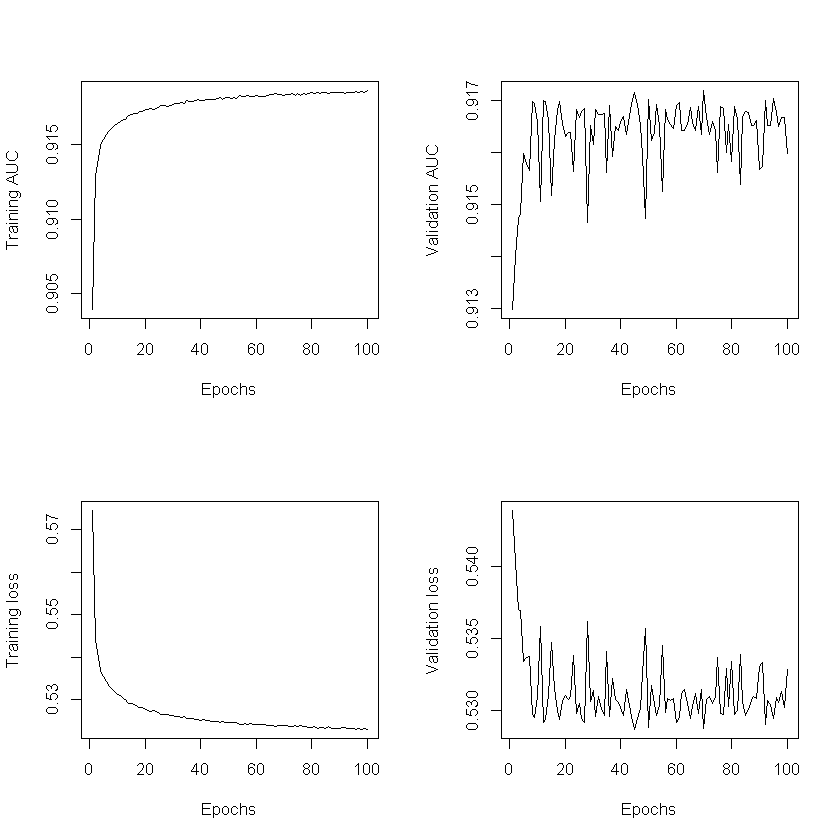

[1] "F1-Score Micro - 3 fold - 100 epochs: 0.755767301905717"
  |============================                                          |  40%

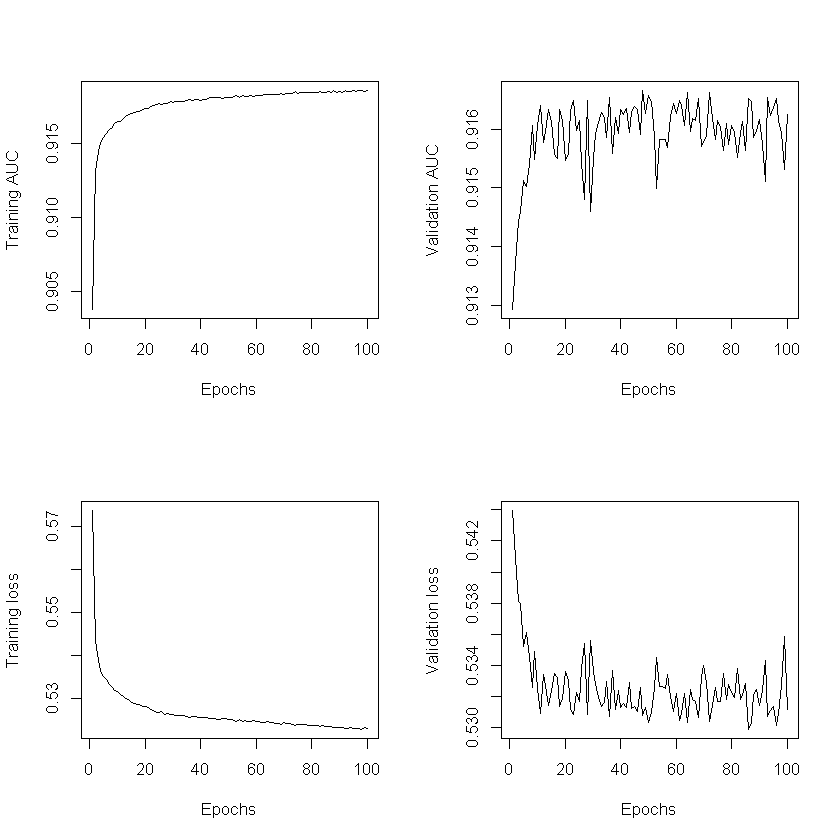

[1] "F1-Score Micro - 4 fold - 100 epochs: 0.755458683743538"
  |===================================                                   |  50%

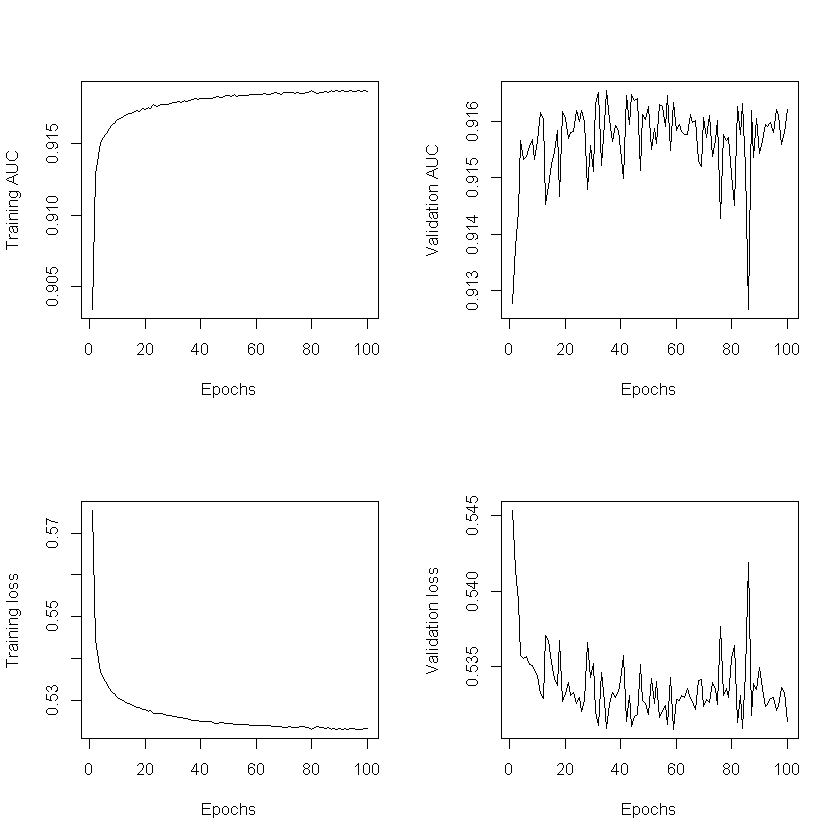

[1] "F1-Score Micro - 5 fold - 100 epochs: 0.7538384383921"
  |==========================================                            |  60%

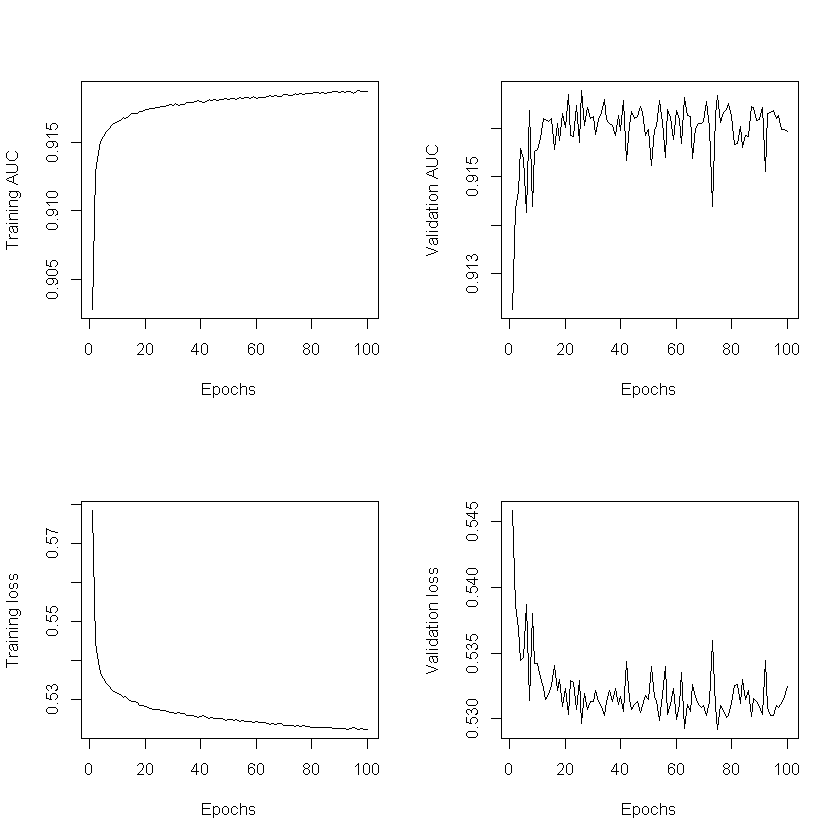

[1] "F1-Score Micro - 6 fold - 100 epochs: 0.751870997608209"
  |=================================================                     |  70%

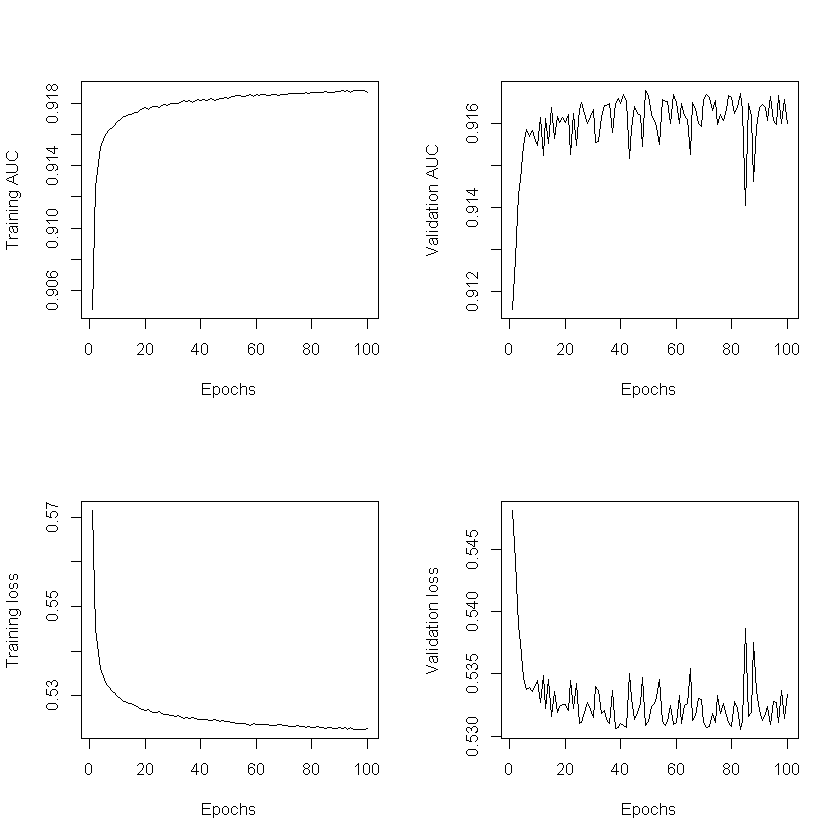

[1] "F1-Score Micro - 7 fold - 100 epochs: 0.755265797392176"
  |========================================================              |  80%

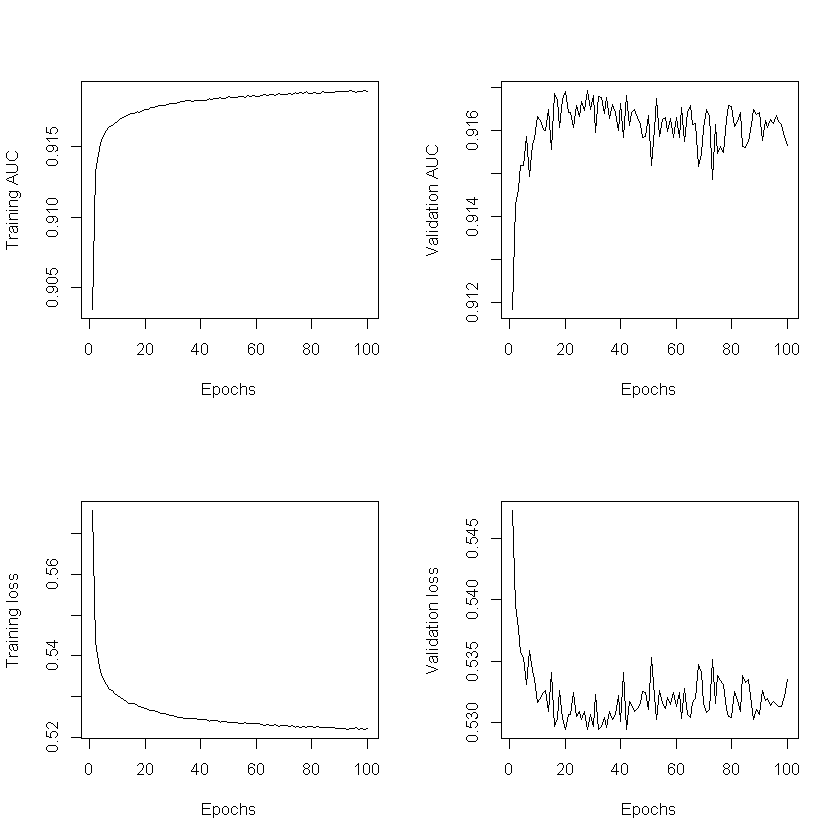

[1] "F1-Score Micro - 8 fold - 100 epochs: 0.756500270040892"
  |===============================================================       |  90%

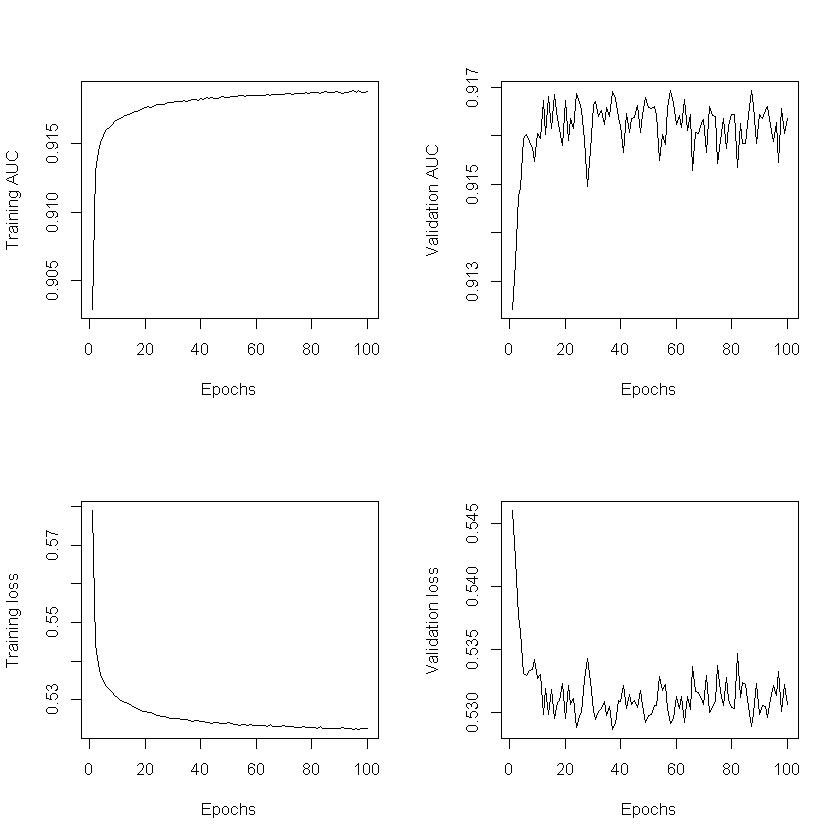

[1] "F1-Score Micro - 9 fold - 100 epochs: 0.757348969986884"
  |======================================================================| 100%

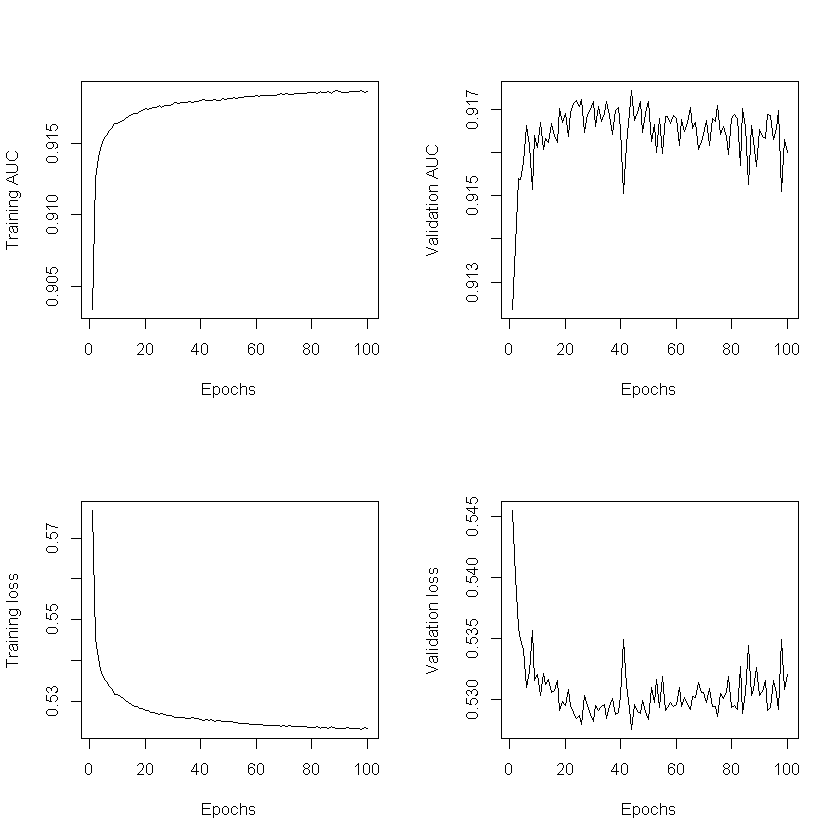

[1] "F1-Score Micro - 10 fold - 100 epochs: 0.754563346582796"


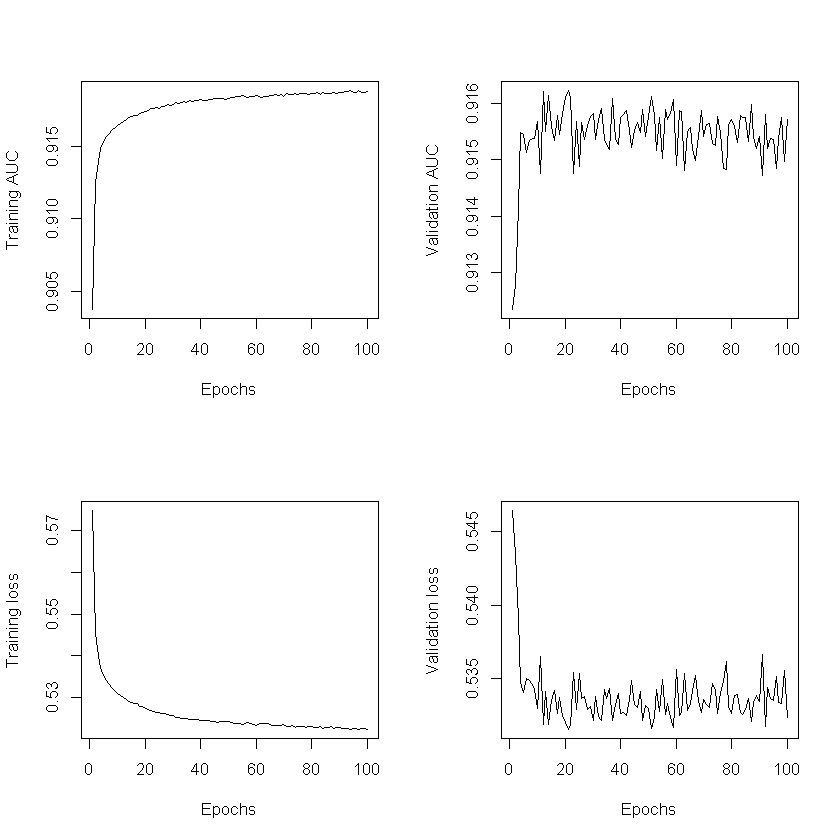

[1] "Mean F1-Score Micro: 0.755129970951776"


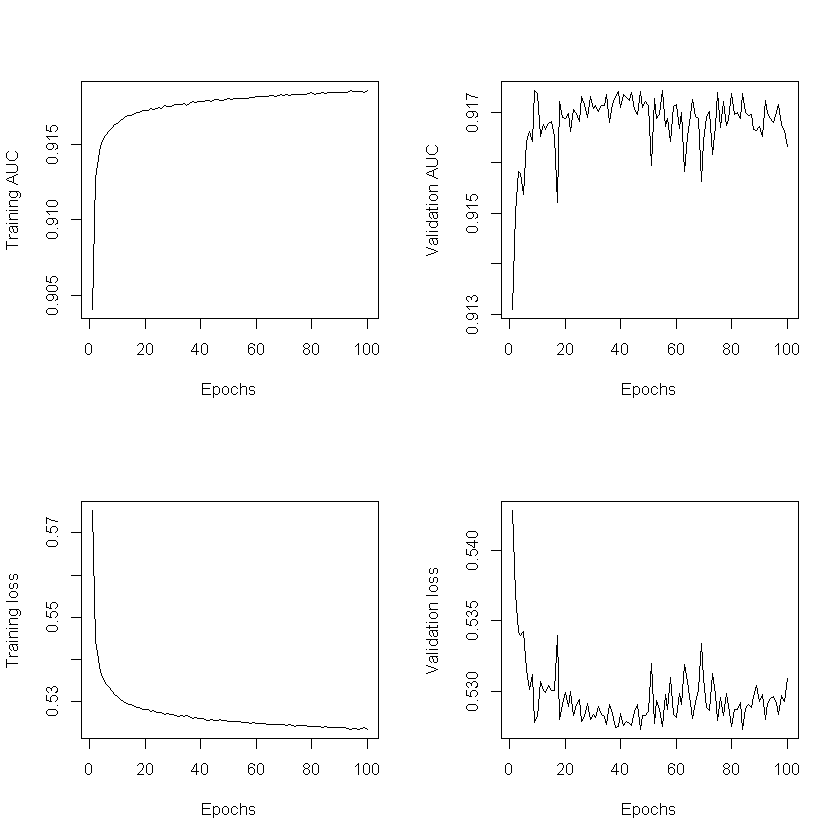

In [25]:
k = 10

accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
target_indices<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in 20:20){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(35, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]


        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_indices]),
        as.matrix(train_data[,target_indices]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 5*j
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_indices]))

        yhaty <- classConverter(yhat,test_data)

        accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
        par(mfrow=c(2,2)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='Training AUC')
        plot(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',xlab="Epochs",ylab='Validation AUC')
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Training loss')
        plot(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',xlab="Epochs",ylab='Validation loss')
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

  |=======                                                               |  10%[1] "F1-Score Micro - 1 fold - 30 epochs: 0.75893063806805"
  |==============                                                        |  20%[1] "F1-Score Micro - 2 fold - 30 epochs: 0.756693156392254"
  |=====================                                                 |  30%

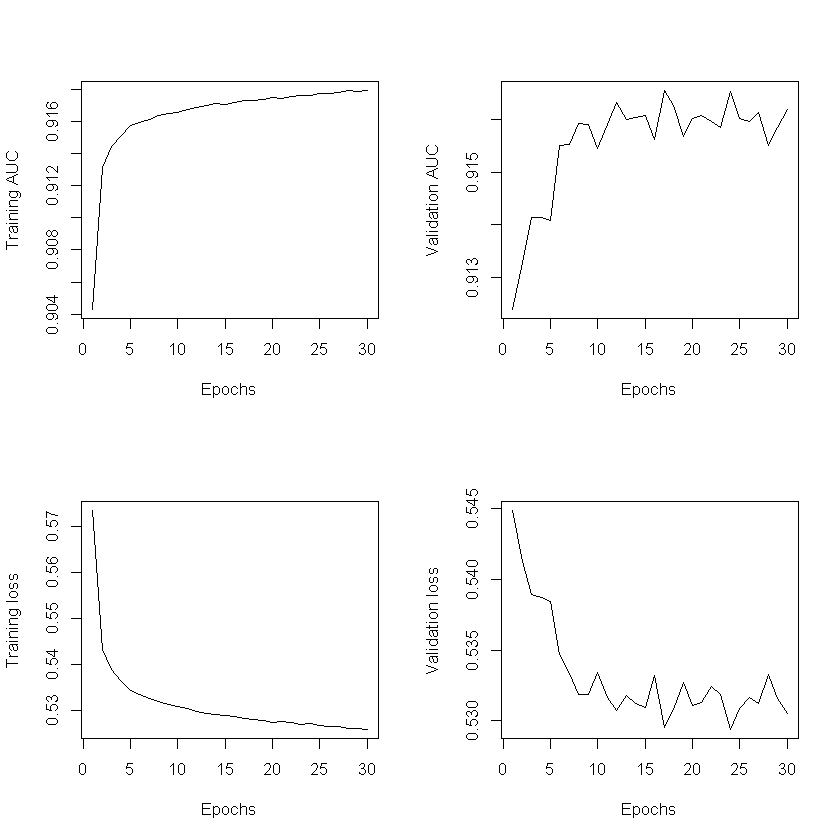

[1] "F1-Score Micro - 3 fold - 30 epochs: 0.753182624797469"
  |============================                                          |  40%

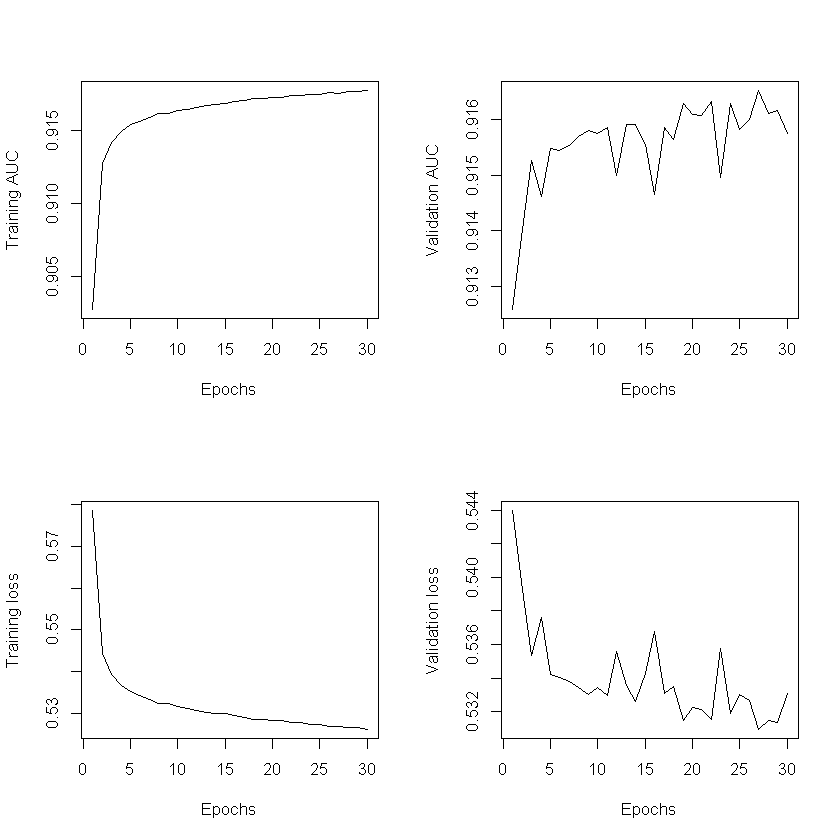

[1] "F1-Score Micro - 4 fold - 30 epochs: 0.754609983797546"
  |===================================                                   |  50%

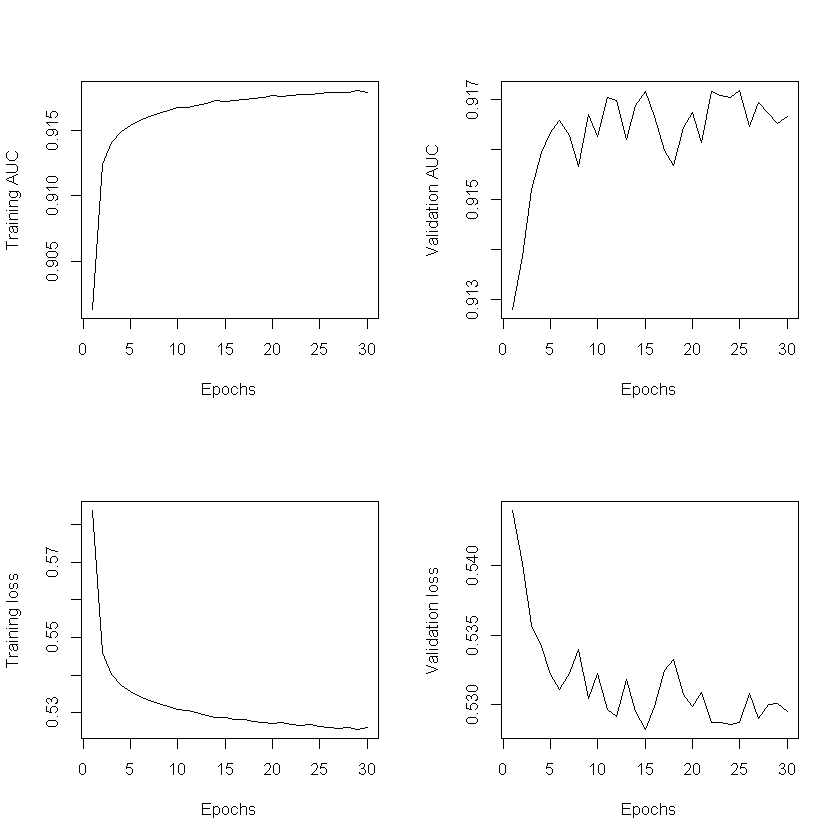

[1] "F1-Score Micro - 5 fold - 30 epochs: 0.750212174986498"
  |==========================================                            |  60%

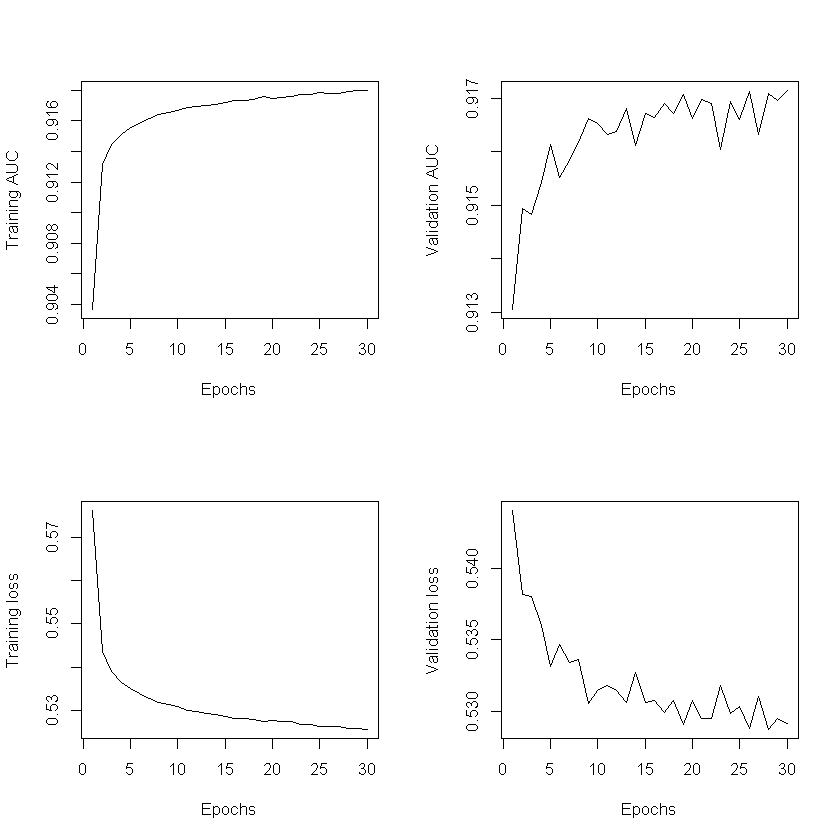

[1] "F1-Score Micro - 6 fold - 30 epochs: 0.755690147365172"
  |=================================================                     |  70%

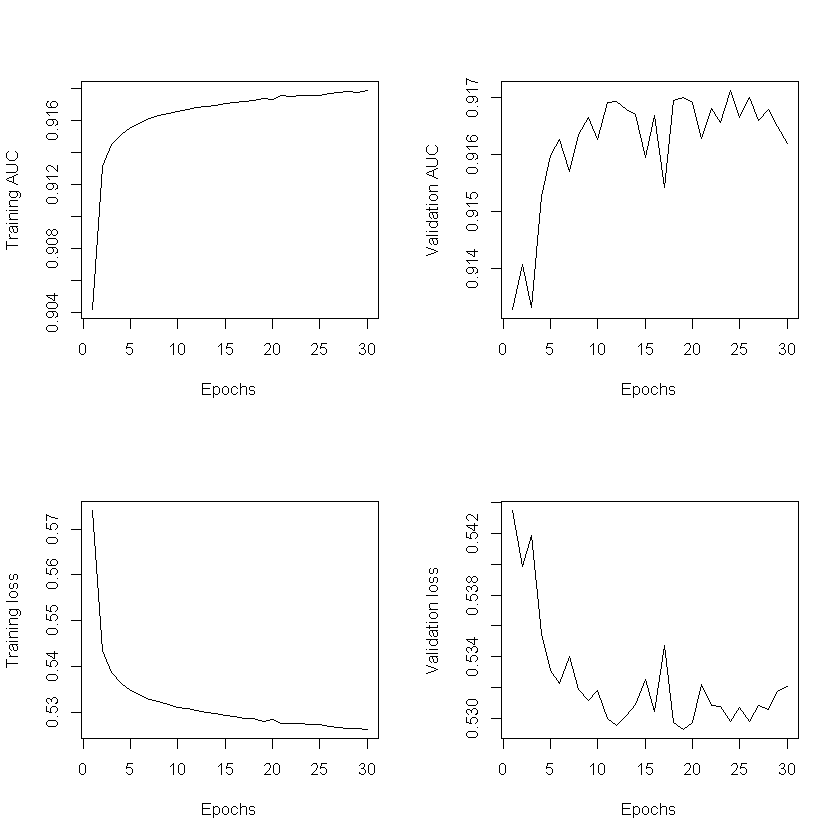

[1] "F1-Score Micro - 7 fold - 30 epochs: 0.752989738446108"
  |========================================================              |  80%

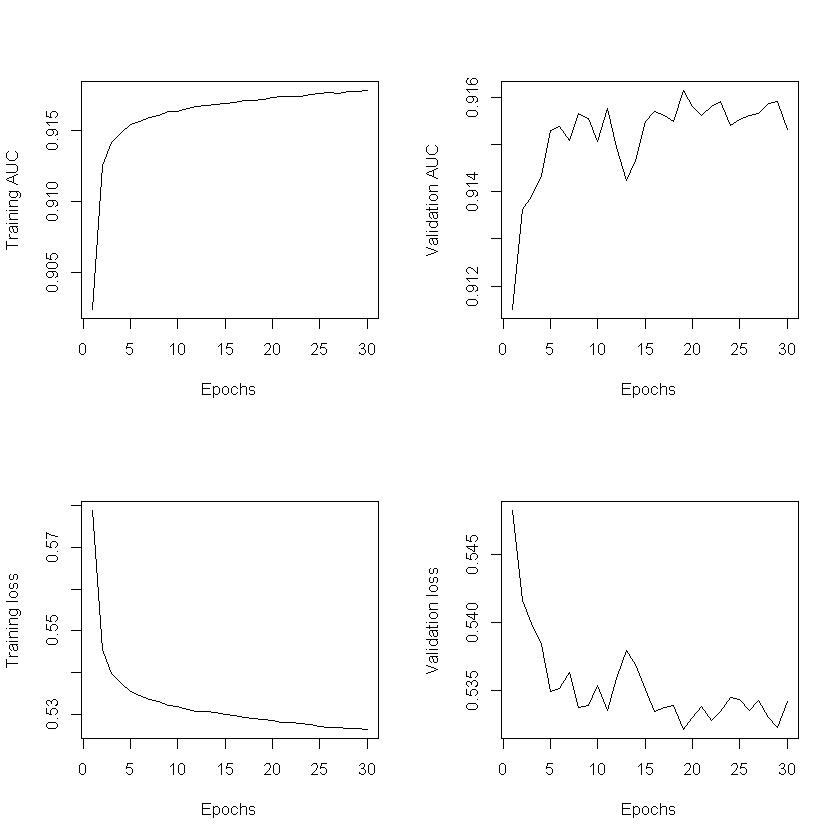

[1] "F1-Score Micro - 8 fold - 30 epochs: 0.758390556284237"
  |===============================================================       |  90%

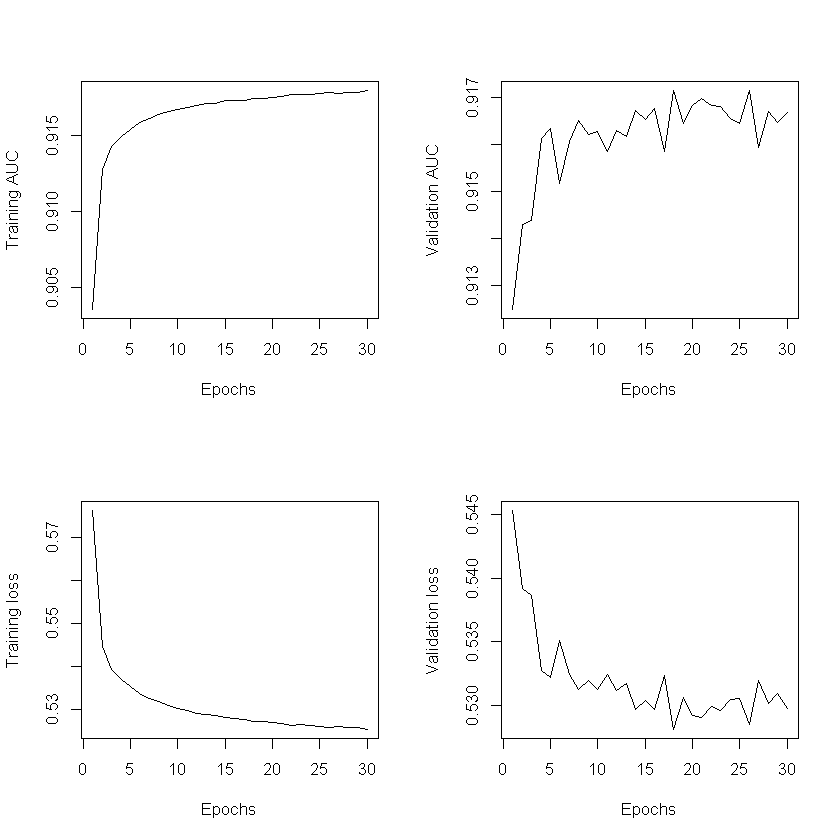

[1] "F1-Score Micro - 9 fold - 30 epochs: 0.753761283851555"
  |======================================================================| 100%

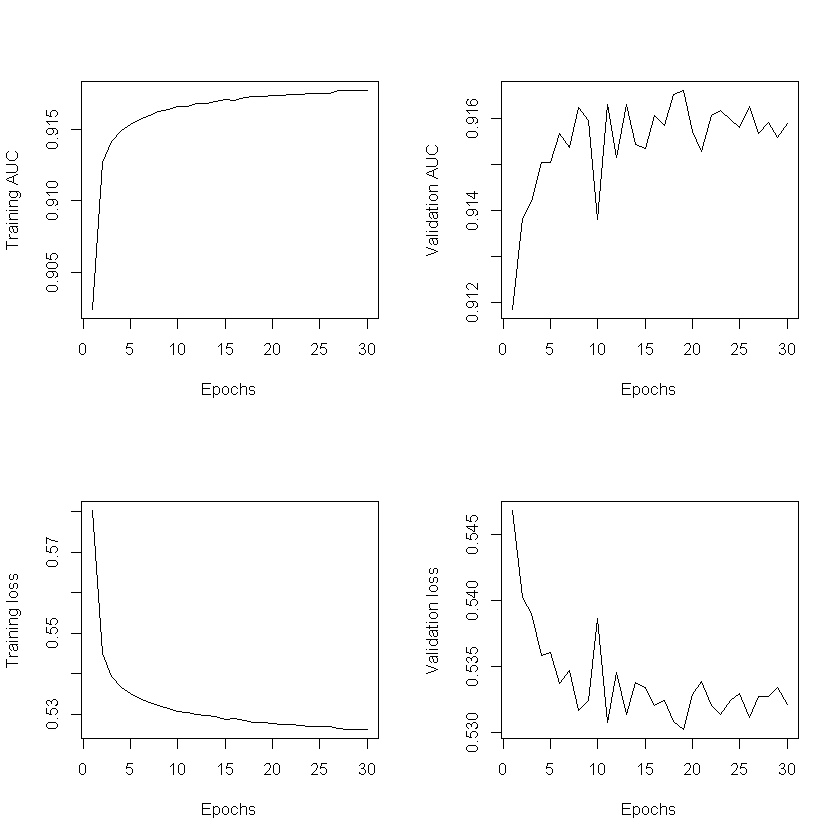

[1] "F1-Score Micro - 10 fold - 30 epochs: 0.759695905530043"


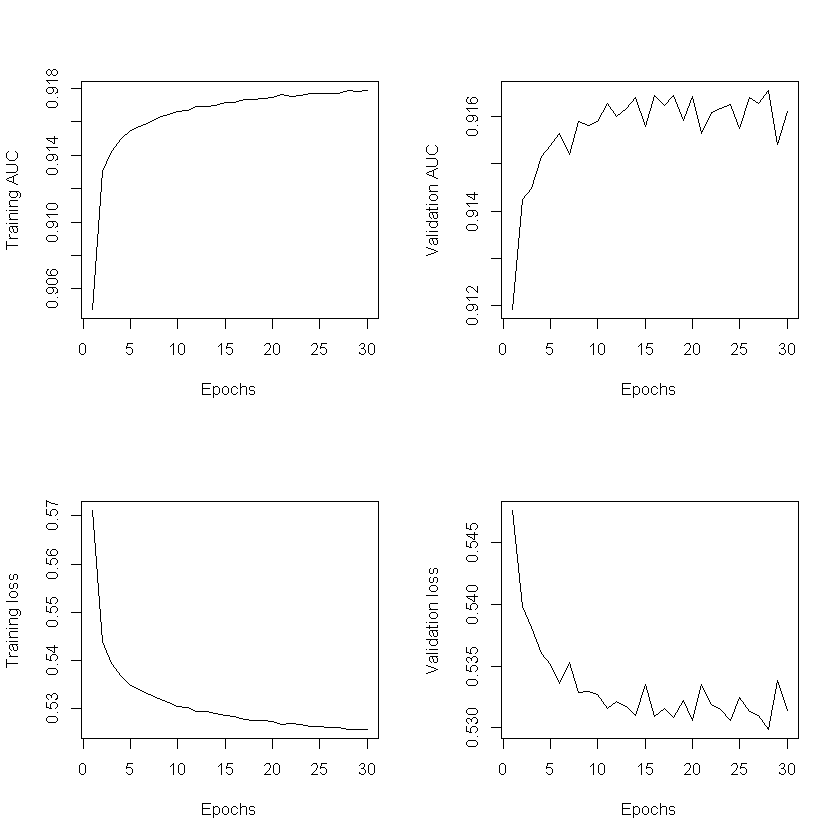

[1] "Mean F1-Score Micro: 0.755415620951893"


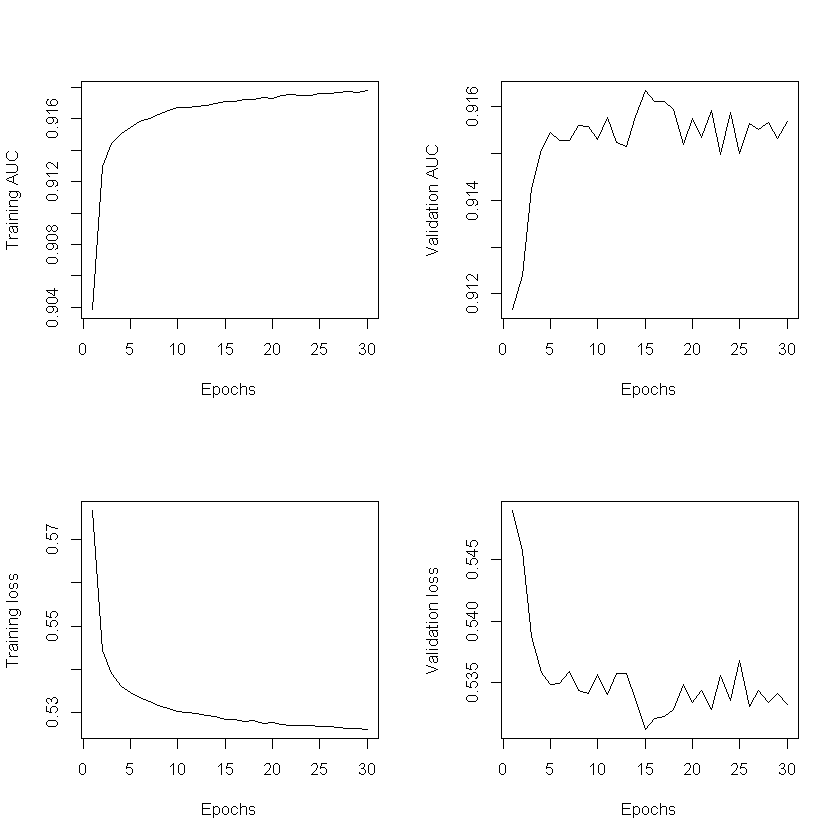

In [26]:
k = 10

accuracy_vec <- array(0,k)

nrows<-nrow(dataNN)
target_indices<-which(grepl('damage_grade',colnames(dataNN)))

# 1. Shuffle the dataset randomly.
dataNN_idx <- sample(1:nrows)

# 2. Split the dataset into k groups
max <- ceiling(nrows/k)
splits <- split(dataNN_idx, ceiling(seq_along(dataNN_idx)/max))

pb <- txtProgressBar(min = 0, max = k, style = 3)
# 3. For each unique group:
for (i in 1:k){
    for (j in 6:6){
        
        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(35, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        #3.1 Take the group as a hold out or test data set
        test_data <- dataNN[splits[[i]],]


        #3.2 Take the remaining groups as a training data set
        train_data <- dataNN[-splits[[i]],]   

        model_history <- neuralmodel %>% fit(
        as.matrix(train_data[,-target_indices]),
        as.matrix(train_data[,target_indices]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 5*j
        )

        yhat <- predict(neuralmodel, as.matrix(test_data[-target_indices]))

        yhaty <- classConverter(yhat,test_data)

        accuracy_vec[i]<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        setTxtProgressBar(pb, i)
        print(paste("F1-Score Micro -",i,"fold -", 5*j,'epochs:',accuracy_vec[i]))
        par(mfrow=c(2,2)) 
        plot(1:model_history$params$epochs,model_history$metrics$auc, type='l',xlab="Epochs",ylab='Training AUC')
        plot(1:model_history$params$epochs,model_history$metrics$val_auc, type='l',xlab="Epochs",ylab='Validation AUC')
        plot(1:model_history$params$epochs,model_history$metrics$loss, type='l',xlab="Epochs",ylab='Training loss')
        plot(1:model_history$params$epochs,model_history$metrics$val_loss, type='l',xlab="Epochs",ylab='Validation loss')
        rm('neuralmodel','model_history')
    }
}

#4. Summarize the accuracy of the model using the sample of model evaluation scores
print(paste("Mean F1-Score Micro:",mean(accuracy_vec)))

In [5]:
dataNN_test<-read.csv("testNN_target_encoding.csv",stringsAsFactors = T)
id_variable <- match('building_id',colnames(dataNN_test))

test_predict <- predict(neuralmodel, as.matrix(dataNN_test[,-c(id_variable)]))

neuralmodel <- keras_model_sequential() %>% 
    normalizer  %>% 
    layer_dense(35, activation = 'relu') %>%
    layer_dense(3,activation='softmax')

    neuralmodel %>% compile(
        loss = 'categorical_crossentropy',
        optimizer = optimizer_adam(0.001),
        metrics=c('AUC')
    )

    model_history <- neuralmodel %>% fit(
    as.matrix(dataNN[,-target_indices]),
    as.matrix(dataNN[,target_indices]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 5
    )

    yhat <- predict(neuralmodel, as.matrix(dataNN_test))

test_predict_f<-data.frame(matrix(0,ncol = 2, nrow = nrow(yhat)))
colnames(test_predict_f)<-c('building_id','damage_grade')

for (i in 1:nrow(test_predict)){
    test_predict_f[i,1]<-ids[i,1]
    test_predict_f[i,2]<-which.max(yhat[i,])
}
write.csv(test_predict_f,'prediction_temp_NN.csv',col.names=TRUE,row.names=FALSE)


ERROR: Error in eval(expr, envir, enclos): objet 'neuralmodel' introuvable


In [16]:
accuracy_vec <- data.frame(matrix(ncol = 2, nrow = 0))
for (i in 1:20){
  print(paste('Number of epochs:',5*i))
  yhat <- neuralmodel %>% fit(
    as.matrix(train_data[,-target_indices]),
    as.matrix(train_data[,target_indices]),
    validation_split = 0.2,
    verbose = 0,
    epochs = 5*i
  )
  yhat
  yhatt<-neuralmodel  %>% evaluate(
      as.matrix(test_data[,-target_indices]),
      as.matrix(test_data[,target_indices]),
  )
  yhatt
  yhattt <- predict(neuralmodel, as.matrix(test_data[-target_indices]))
  yhattt
  yhat_f<-data.frame(matrix(0,ncol = 1, nrow = nrow(yhattt)))
  y_f<-data.frame(matrix(0,ncol = 1, nrow = nrow(yhattt)))
  for (i in 1:nrow(yhattt)){
    yhat_f[i,]<-which.max(yhattt[i,])
    y_f[i,]<-which.max(test_data[i,target_indices])  
  }
  colnames(yhat_f)<-'damage_grade'
  colnames(y_f)<-'damage_grade'
  score<-F1_Score_micro(as.factor(y_f[,]),as.factor(yhat_f[,]))
  accuracy_vec[nrow(accuracy_vec)+1,]<-c(5*i,score)
  print(paste('F1 Score Micro: ',score))
  rm('yhat','yhatt','yhattt','neuralmodel')

}
accuracy_vec

[1] "Number of epochs: 5"
[1] "F1 Score Micro:  0.747625717081407"
[1] "Number of epochs: 10"
[1] "F1 Score Micro:  0.747146063966539"
[1] "Number of epochs: 15"
[1] "F1 Score Micro:  0.745035590261123"
[1] "Number of epochs: 20"
[1] "F1 Score Micro:  0.745918151992479"
[1] "Number of epochs: 25"
[1] "F1 Score Micro:  0.745323382130044"
[1] "Number of epochs: 30"
[1] "F1 Score Micro:  0.745918151992479"
[1] "Number of epochs: 35"
[1] "F1 Score Micro:  0.747836764451948"
[1] "Number of epochs: 40"
[1] "F1 Score Micro:  0.747241994589513"
[1] "Number of epochs: 45"
[1] "F1 Score Micro:  0.745918151992479"
[1] "Number of epochs: 50"
[1] "F1 Score Micro:  0.748930373553846"
[1] "Number of epochs: 55"
[1] "F1 Score Micro:  0.747318739087891"
[1] "Number of epochs: 60"
[1] "F1 Score Micro:  0.748776884557088"
[1] "Number of epochs: 65"
[1] "F1 Score Micro:  0.747491414209244"
[1] "Number of epochs: 70"
[1] "F1 Score Micro:  0.746973388845187"
[1] "Number of epochs: 75"
[1] "F1 Score Micro:  

,X1,X2
,<dbl>,<dbl>
1,260605,0.7476257
2,260605,0.7471461
3,260605,0.7450356
4,260605,0.7459182
5,260605,0.7453234
6,260605,0.7459182
7,260605,0.7478368
8,260605,0.7472420
9,260605,0.7459182


100 epochs.

2 layers : "F1 Score Micro:  0.743423955795169"

2 layers : "F1 Score Micro:  0.738301260528386"

3 layers : "F1 Score Micro:  0.735346597340803"

4 layers : "F1 Score Micro:  0.741390226588131"

5 layers : "F1 Score Micro:  0.741006504096237"

8 layers : "F1 Score Micro:  0.742714069185165"

10 layers : "F1 Score Micro:  0.736823928934594" 24 min

12 lays : "F1 Score Micro:  0.742675696935976" 28 min

14 layers : "F1 Score Micro:  0.740219872987855" 34 min

(all above layers are 64)


1 layer 35 : "F1 Score Micro:  0.747817578327354" 15 min

1 layer 47 : "F1 Score Micro:  0.747625717081407" 15 min